In [1]:
import pandas as pd
from pygments.styles.dracula import purple

data = pd.read_csv(r"D:\netflix_cleaned.csv")
data.head(7)
data.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [ ]:
data.isnull().sum().sort_values(ascending=False)

In [4]:
data['director'].isnull().mean() #计算为True也就是空白的平均数，除以了总列数。

np.float64(0.29908027705234475)

In [10]:
for c in data.columns:
    percentage=data[c].isnull().mean()
    print(c+': '+str(round(percentage*100,2))+'%')

show_id: 0.0%
type: 0.0%
title: 0.0%
director: 29.91%
cast: 9.37%
country: 9.44%
date_added: 0.11%
release_year: 0.0%
rating: 0.05%
duration: 0.03%
listed_in: 0.0%
description: 0.0%


### **Cleaning the data**

In [ ]:
no_director = data[data['director'].isnull()].index
data.drop(no_director,axis=0).head(7)
data[~(data['director'].isnull())] #也可以用~来进行取反操作和去除
data.dropna(subset='director') #还可以用dropna

In [16]:
data[data['rating'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [15]:
mode_value = data['rating'].mode()[0]
data['rating'] = data['rating'].fillna(mode_value)

In [ ]:
import numpy as np
data['duration']
#fillna with numbers, or back/forword
# 数值列：用 0 填充
data['duration'].fillna('0')
# 字符串列：用后向填充
data['director'] = data['director'].fillna(method='bfill')  #

In [37]:
data_movie = data[data['type'] == 'Movie']
# 提取持续时间数字并转为整数
data_movie['duration_num'] = pd.to_numeric(
    data_movie['duration'].str.split(' ', expand=True)[0],
    errors='coerce'
)
# 可选：删除无效记录
data_movie = data_movie.dropna(subset=['duration_num'])
# 查看结果
print(data_movie[['duration', 'duration_num']].head())

   duration  duration_num
0    90 min          90.0
6    91 min          91.0
7   125 min         125.0
9   104 min         104.0
12  127 min         127.0


In [24]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [35]:
data['date_added'].str.split(',')[1]
data['date_added'].str.extract('(\d{4})')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\28439\AppData\Local\Temp\ipykernel_17464\3879207516.py:2: SyntaxWarning: invalid escape sequence '\d'
  data['date_added'].str.extract('(\d{4})')


,0
0,2021
1,2021
2,2021
3,2021
4,2021
...,...
8802,2019
8803,2019
8804,2019
8805,2020


In [2]:
# 先拆分，再转为整数（自动处理无效值）
data['minute'] = pd.to_numeric(
    data['duration'].str.split(' ', expand=True)[0],
    errors='coerce'  # 把无法转换的变成 NaN
)
data_movie=data

<Axes: ylabel='Frequency'>

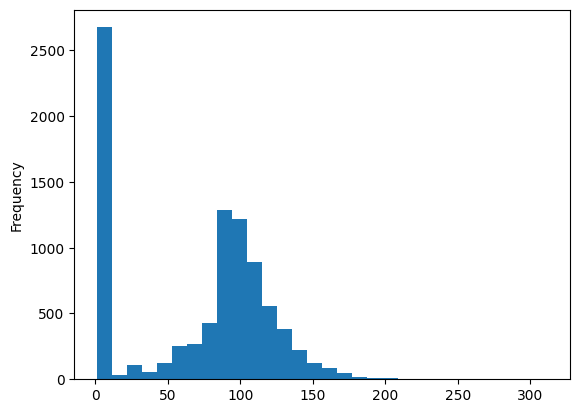

In [3]:
data['minute'].plot(kind='hist',bins=30) #bins是分快数量

In [47]:
data['minute'].value_counts(bins=10).sort_index()

(0.688, 32.1]     2817
(32.1, 63.2]       433
(63.2, 94.3]      1981
(94.3, 125.4]     2662
(125.4, 156.5]     730
(156.5, 187.6]     150
(187.6, 218.7]      22
(218.7, 249.8]       6
(249.8, 280.9]       2
(280.9, 312.0]       1
Name: count, dtype: int64

In [53]:
data_movie[(data_movie['minute']>30) & (data_movie['minute']<90)].head() #筛选的时候又忘记加括号了哈哈哈

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...,67.0
23,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",NaN,"September 21, 2021",2021,TV-Y,61 min,Children & Family Movies,From arcade games to sled days and hiccup cure...,61.0
53,s54,Movie,InuYasha the Movie 4: Fire on the Mystic Island,Toshiya Shinohara,"Kappei Yamaguchi, Satsuki Yukino, Koji Tsujita...",Japan,"September 15, 2021",2004,TV-PG,88 min,"Action & Adventure, Anime Features, Internatio...","Ai, a young half-demon who has escaped from Ho...",88.0
60,s61,Movie,Naruto Shippuden: The Movie: The Lost Tower,Masahiko Murata,"Junko Takeuchi, Chie Nakamura, Satoshi Hino, R...",Japan,"September 15, 2021",2010,TV-14,85 min,"Action & Adventure, Anime Features, Internatio...","When Naruto is sent to recover a missing nin, ...",85.0
63,s64,Movie,Naruto the Movie: Ninja Clash in the Land of Snow,Tensai Okamura,"Junko Takeuchi, Noriaki Sugiyama, Chie Nakamur...",Japan,"September 15, 2021",2004,TV-PG,83 min,"Action & Adventure, Anime Features, Internatio...","Naruto, Sasuke and Sakura learn they'll be pro...",83.0


### **Boxplot to see outliers**

<Axes: >

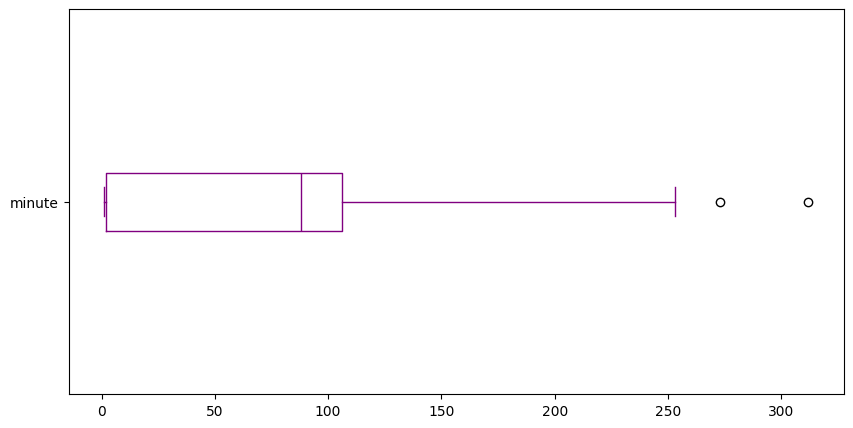

In [61]:
data_movie['minute'].plot(kind='box',vert=False,color='purple',figsize=(10,5))

In [63]:
#IQR = Q3 -Q1
#Q1-1.5*IQR
min_boxplot=2-1.5*(106-2)
#Q3=1.5+IQR
max_boxplot=106+1.5*(106-2)
print(min_boxplot)
print(max_boxplot)

-154.0
262.0


In [64]:
data_movie['minute'].describe()

count    8804.000000
mean       69.846888
std        50.814828
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: minute, dtype: float64

### **Using Bars to see outliers**

<Axes: xlabel='rating'>

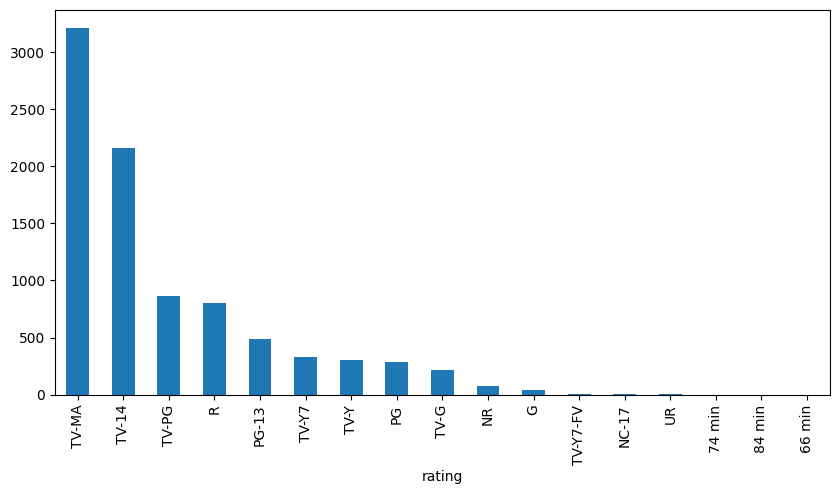

In [5]:
data_movie['rating'].value_counts().plot(kind='bar',figsize=(10,5))

### **Dealing with some string**

In [11]:
#data_movie['title'].str.lower()，.str后面还能跟upper，title等
data_movie['title']=data_movie['title'].str.title()
data_movie['title'].apply(lambda x:x.title())#lambda 表达式也可以
data_movie.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0


### **Remove blank with strip**

In [16]:
m_title = ' Tantanic  '
m_title
m_title.lstrip()
m_title.rstrip()
m_title.strip()

'Tantanic'

In [18]:
data_movie['title'].str.strip()
data_movie['title'].apply(lambda x:x.strip())

0        Dick Johnson Is Dead
1               Blood & Water
2                   Ganglands
3       Jailbirds New Orleans
4                Kota Factory
                ...          
8802                   Zodiac
8803              Zombie Dumb
8804               Zombieland
8805                     Zoom
8806                   Zubaan
Name: title, Length: 8807, dtype: str

In [19]:
#Remove Punctuations
data_movie['title'].str.replace('[^\w\s]','',regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\28439\AppData\Local\Temp\ipykernel_19004\3538879321.py:1: SyntaxWarning: invalid escape sequence '\w'
  data_movie['title'].str.replace('[^\w\s]','',regex=True)


0        Dick Johnson Is Dead
1                Blood  Water
2                   Ganglands
3       Jailbirds New Orleans
4                Kota Factory
                ...          
8802                   Zodiac
8803              Zombie Dumb
8804               Zombieland
8805                     Zoom
8806                   Zubaan
Name: title, Length: 8807, dtype: str